# 2 — Partager un budget carbone mondial

Une trajectoire mondiale ne dit pas quelle part revient à un pays, un secteur ou une personne. Cette seconde étape introduit quatre **principes de partage** fréquemment mobilisés dans les exercices de descente d'échelle :

1. l'égalité par habitant ;
2. le maintien des droits acquis (*grandfathering*) ;
3. l'allocation proportionnelle au PIB ;
4. la capacité à agir, approchée par le PIB par habitant.

Ce notebook fournit un point de départ, pas un catalogue exhaustif. Votre travail consistera notamment à rechercher d'autres principes, à reconstituer leur logique et à discuter leurs implications.

> **Objectifs.** Savoir traduire un principe en ratio d'allocation, contrôler le calcul, produire des trajectoires nationales et distinguer une convention technique d'un choix de justice.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (11, 5), "font.size": 11})

RACINE = Path.cwd()
if not (RACINE / "data").exists():
    RACINE = RACINE.parent
DONNEES = RACINE / "data" / "raw"
FIGURES = RACINE / "figures"
FIGURES.mkdir(exist_ok=True)

ANNEE_REFERENCE = 2023
PAYS_ETUDIE = "BEN"  # Modifiez ce code ISO pour explorer un autre pays.
PAYS_COMPARAISON = ["BEN", "IND", "BRA", "CHN", "FRA", "LUX", "USA"]
NOMS_FR = {
    "BEN": "Bénin", "IND": "Inde", "BRA": "Brésil", "CHN": "Chine",
    "FRA": "France", "LUX": "Luxembourg", "USA": "États-Unis",
}

## 1. Du budget mondial à la part d'un pays

Pour le pays $i$ et l'année $t$ :

$$B_{i,t} = s_i \times B_{monde,t}$$

- $B_{monde,t}$ est le budget écologique mondial annuel compatible avec la trajectoire choisie ;
- $s_i$ est le ratio d'allocation du pays ;
- la somme des ratios doit être égale à 1 sur le périmètre retenu.

Le principe de partage détermine le calcul de $s_i$. Comme le rappelle le [SDES](https://www.statistiques.developpement-durable.gouv.fr/edition-numerique/la-france-face-aux-neuf-limites-planetaires/partie3-quelles-utilisations-du-cadre-des-limites), ce choix doit être apprécié à la fois sur les plans technique et éthique.

**Point de vigilance.** Comparer des principes calculés sur des listes de pays différentes confondrait l'effet du principe et l'effet de la couverture statistique. Nous construisons donc un périmètre commun.

## 2. Préparer un jeu de données commun

Les données sont déjà présentes dans le dépôt. Nous utilisons une année commune — 2023 — et quatre variables : population, PIB en parité de pouvoir d'achat (PPA), PIB en PPA par habitant et émissions territoriales de GES incluant l'usage des sols.

Les séries économiques proviennent de la Banque mondiale et sont redistribuées par Our World in Data. Les émissions territoriales constituent ici un **proxy** : le rapport EEA/FOEN mobilise une empreinte de consommation pour le maintien des droits acquis.

In [2]:
def pays_pour_annee(fichier, variable, nouveau_nom, annee=ANNEE_REFERENCE):
    """Sélectionne les pays dotés d'un code ISO à trois lettres."""
    brut = pd.read_csv(DONNEES / fichier)
    masque = (brut["Year"] == annee) & brut["Code"].str.fullmatch(r"[A-Z]{3}", na=False)
    return (
        brut.loc[masque, ["Entity", "Code", variable]]
        .rename(columns={"Entity": "pays", "Code": "code", variable: nouveau_nom})
        .dropna(subset=[nouveau_nom])
        .drop_duplicates("code")
    )

population = pays_pour_annee("population_owid.csv", "Population", "population")
pib = pays_pour_annee("pib_ppa_banque_mondiale_owid.csv", "GDP", "pib_ppa")
pib_hab = pays_pour_annee(
    "pib_ppa_par_habitant_banque_mondiale_owid.csv",
    "GDP per capita", "pib_ppa_par_habitant"
)
emissions = pays_pour_annee(
    "greenhouse-gas-emissions.csv",
    "Annual greenhouse gas emissions including land use", "emissions_ges_t"
)

indicateurs = (
    population
    .merge(pib.drop(columns="pays"), on="code", validate="one_to_one")
    .merge(pib_hab.drop(columns="pays"), on="code", validate="one_to_one")
    .merge(emissions.drop(columns="pays"), on="code", validate="one_to_one")
    .set_index("code").sort_index()
)

couverture = indicateurs["population"].sum() / population["population"].sum()
print(f"{len(indicateurs)} pays dans le périmètre commun")
print(f"{couverture:.1%} de la population des pays renseignés est couverte")
apercu = indicateurs.loc[PAYS_COMPARAISON].copy()
apercu["pays"] = [NOMS_FR.get(code, nom) for code, nom in zip(apercu.index, apercu["pays"])]
apercu

186 pays dans le périmètre commun
97.8% de la population des pays renseignés est couverte


,pays,population,pib_ppa,pib_ppa_par_habitant,emissions_ges_t
code,,,,,
BEN,Bénin,14111035,52510156788,3721.2126,4.030051e+07
IND,Inde,1438069597,12756468651839,8870.5500,4.121424e+09
BRA,Brésil,211140731,4028525459920,19079.8120,2.817818e+09
CHN,Chine,1422584930,32005133203227,22687.2520,1.393440e+10
FRA,France,66438828,3712391079956,54296.7230,3.451346e+08
LUX,Luxembourg,665101,86668503270,130048.9200,7.770276e+06
USA,États-Unis,343477330,25038301109944,74351.6700,6.078455e+09


### Contrôle préalable

La couverture n'est jamais un détail neutre. Quels pays sont absents ? Les données manquantes sont-elles réparties au hasard ? Leur exclusion risque-t-elle de favoriser certains principes ? Dans un travail de recherche, on conserverait un tableau des pays inclus et exclus pour chaque variable.

## 3. Quatre principes, quatre conceptions du partage

On définit un **poids** pour chaque pays, puis on divise chaque poids par la somme mondiale des poids :

$$s_i = \frac{w_i}{\sum_j w_j}$$

In [3]:
def normaliser(poids):
    """Transforme des poids positifs en ratios dont la somme vaut 1."""
    poids = pd.Series(poids, dtype=float)
    if poids.isna().any() or (~np.isfinite(poids)).any():
        raise ValueError("Les poids contiennent des valeurs manquantes ou infinies.")
    if (poids < 0).any() or poids.sum() <= 0:
        raise ValueError("Les poids doivent être positifs et leur somme non nulle.")
    return poids / poids.sum()

def poids_capacite(table, seuil_bas=10_000, seuil_haut=100_000):
    """Population pondérée par l'inverse du niveau de revenu entre deux seuils."""
    revenu_borne = table["pib_ppa_par_habitant"].clip(seuil_bas, seuil_haut)
    coefficient = 1 - (revenu_borne - seuil_bas) / (seuil_haut - seuil_bas)
    return table["population"] * coefficient

parts = pd.DataFrame(index=indicateurs.index)
parts["Égalité par habitant"] = normaliser(indicateurs["population"])

# Les émissions territoriales négatives dues à l'usage des sols sont ramenées à zéro.
# Sans ce choix explicite, certains pays recevraient un budget négatif.
parts["Maintien des droits acquis"] = normaliser(
    indicateurs["emissions_ges_t"].clip(lower=0)
)
parts["Poids économique (PIB)"] = normaliser(indicateurs["pib_ppa"])
parts["Capacité à agir"] = normaliser(poids_capacite(indicateurs))

pd.DataFrame({
    "somme des ratios": parts.sum(),
    "ratio minimal": parts.min(),
    "ratio maximal": parts.max(),
})

,somme des ratios,ratio minimal,ratio maximal
Égalité par habitant,1.0,1.243850e-06,0.181838
Maintien des droits acquis,1.0,3.625195e-07,0.261330
Poids économique (PIB),1.0,3.151251e-07,0.193309
Capacité à agir,1.0,0.000000e+00,0.210871


### A. Égalité par habitant

$w_i = population_i$. Chaque personne reçoit la même fraction du budget mondial. Le principe est lisible, mais il ne prend directement en compte ni les émissions historiques, ni les besoins particuliers, ni les capacités à financer la transition.

### B. Maintien des droits acquis (*grandfathering*)

$w_i = émissions_i$. La répartition actuelle des émissions est prolongée. Cette méthode facilite parfois la continuité économique, mais elle avantage les pays qui émettent déjà beaucoup. Ici, les émissions territoriales remplacent l'empreinte de consommation : ce choix change le sens du résultat.

### C. Poids économique

$w_i = PIB_i$. La règle protège davantage les économies de grande taille, mais elle assimile implicitement création de valeur économique et droit à émettre.

### D. Capacité à agir

$w_i = population_i \times coefficient_i$. Le coefficient décroît de 1 à 0 lorsque le PIB par habitant passe de 10 000 à 100 000 dollars internationaux. Les pays les moins favorisés reçoivent une part plus importante. Les deux seuils sont des paramètres normatifs.

In [4]:
comparaison_parts = parts.loc[PAYS_COMPARAISON].mul(100)
comparaison_parts.index = [NOMS_FR.get(code, code) for code in PAYS_COMPARAISON]
comparaison_parts.index.name = "pays"
comparaison_parts.round(3)

,Égalité par habitant,Maintien des droits acquis,Poids économique (PIB),Capacité à agir
pays,,,,
Bénin,0.178,0.076,0.032,0.207
Inde,18.184,7.729,7.705,21.087
Brésil,2.670,5.285,2.433,2.784
Chine,17.988,26.133,19.331,17.919
France,0.840,0.647,2.242,0.495
Luxembourg,0.008,0.015,0.052,0.000
États-Unis,4.343,11.400,15.123,1.435


**Lecture.** Les valeurs sont des pourcentages du budget mondial. Avant d'expliquer les écarts, reformulez chaque règle en une phrase sans utiliser son nom : « ce pays reçoit davantage parce que… »

## 4. Appliquer les ratios aux trajectoires C1 et C3

Nous utilisons les médianes des familles C1 et C3. Les ratios sont maintenus constants : les populations, les économies et les émissions relatives sont donc supposées figées à leur niveau de 2023. Cette hypothèse simplifie le premier calcul, mais devra être discutée.

In [5]:
def charger_mediane(nom_fichier):
    donnees = pd.read_csv(DONNEES / nom_fichier, index_col=0).T
    donnees.index = donnees.index.astype(int)
    return donnees["Median"].astype(float)

trajectoires_mondiales = pd.DataFrame({
    "C1": charger_mediane("c1_pathway_IPCC.csv"),
    "C3": charger_mediane("c3_pathway_IPCC.csv"),
})
trajectoires_mondiales.index.name = "année"

def trajectoires_nationales(code_pays):
    """Budgets annuels d'un pays, en Mt CO2-éq/an."""
    resultats = {}
    for categorie in trajectoires_mondiales:
        for principe in parts:
            resultats[(categorie, principe)] = (
                trajectoires_mondiales[categorie]
                * parts.loc[code_pays, principe] * 1_000
            )
    table = pd.DataFrame(resultats)
    table.columns.names = ["catégorie", "principe"]
    return table

budget_pays = trajectoires_nationales(PAYS_ETUDIE)
budget_pays.loc[[2026, 2030, 2040, 2050]].round(2)

catégorie                   C1                             \
principe  Égalité par habitant Maintien des droits acquis   
année                                                       
2026                     70.01                      29.66   
2030                     55.17                      23.37   
2040                     32.61                      13.81   
2050                     17.72                       7.51   

catégorie                                                          C3  \
principe  Poids économique (PIB) Capacité à agir Égalité par habitant   
année                                                                   
2026                       12.44           81.19                88.41   
2030                        9.81           63.98                79.88   
2040                        5.80           37.82                53.01   
2050                        3.15           20.55                35.18   

catégorie                                                                    
principe  Maintien des droits acquis Poids économique (PIB) Capacité à agir  
année                                                                        
2026                           37.45                  15.71          102.52  
2030                           33.84                  14.20           92.64  
2040                           22.45                   9.42           61.47  
2050                           14.90                   6.25           40.79

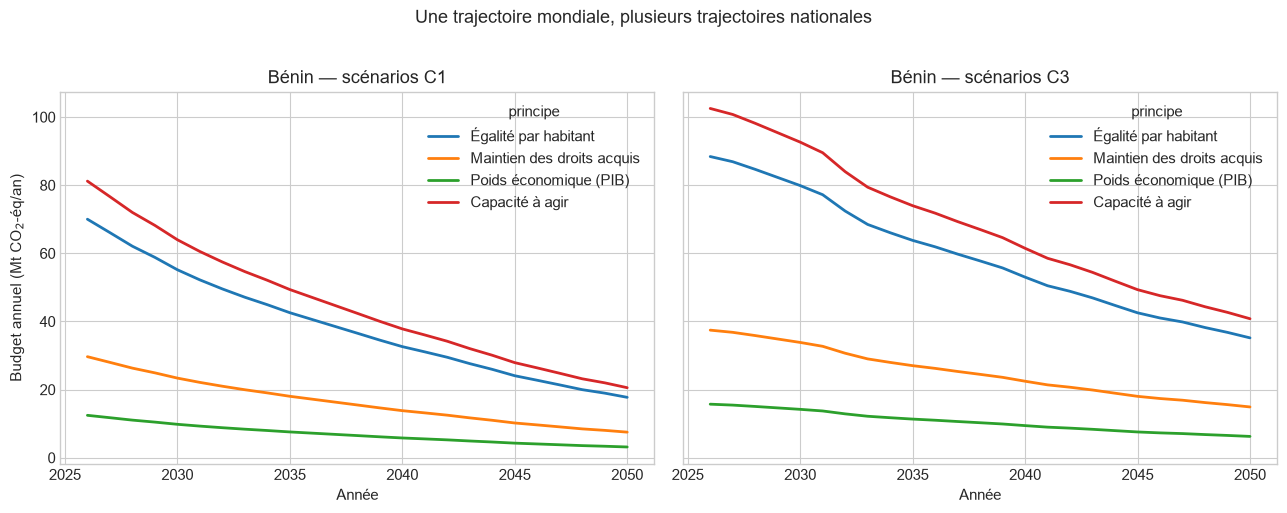

In [6]:
nom_pays = NOMS_FR.get(PAYS_ETUDIE, indicateurs.loc[PAYS_ETUDIE, "pays"])
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, categorie in zip(axes, ["C1", "C3"]):
    budget_pays[categorie].loc[:2050].plot(ax=ax, lw=2)
    ax.set(title=f"{nom_pays} — scénarios {categorie}", xlabel="Année")
    ax.set_ylabel(r"Budget annuel (Mt CO$_2$-éq/an)")
fig.suptitle("Une trajectoire mondiale, plusieurs trajectoires nationales", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES / f"02_trajectoires_{PAYS_ETUDIE.lower()}.png", dpi=180, bbox_inches="tight")
plt.show()

### Comparer les budgets par habitant

Un budget national élevé peut simplement refléter une population nombreuse. L'expression en tonnes de CO₂-éq par personne rend les effets distributifs plus visibles.

In [7]:
budget_2030_par_habitant = (
    parts.mul(trajectoires_mondiales.loc[2030, "C3"] * 1e9)
    .div(indicateurs["population"], axis=0)
)
a_tracer = budget_2030_par_habitant.loc[PAYS_COMPARAISON].copy()
a_tracer.index = [NOMS_FR.get(code, code) for code in PAYS_COMPARAISON]
a_tracer.index.name = "pays"
a_tracer.round(2)

,Égalité par habitant,Maintien des droits acquis,Poids économique (PIB),Capacité à agir
pays,,,,
Bénin,5.66,2.40,1.01,6.57
Inde,5.66,2.41,2.40,6.57
Brésil,5.66,11.21,5.16,5.90
Chine,5.66,8.22,6.08,5.64
France,5.66,4.36,15.11,3.33
Luxembourg,5.66,9.81,35.24,0.00
États-Unis,5.66,14.86,19.71,1.87


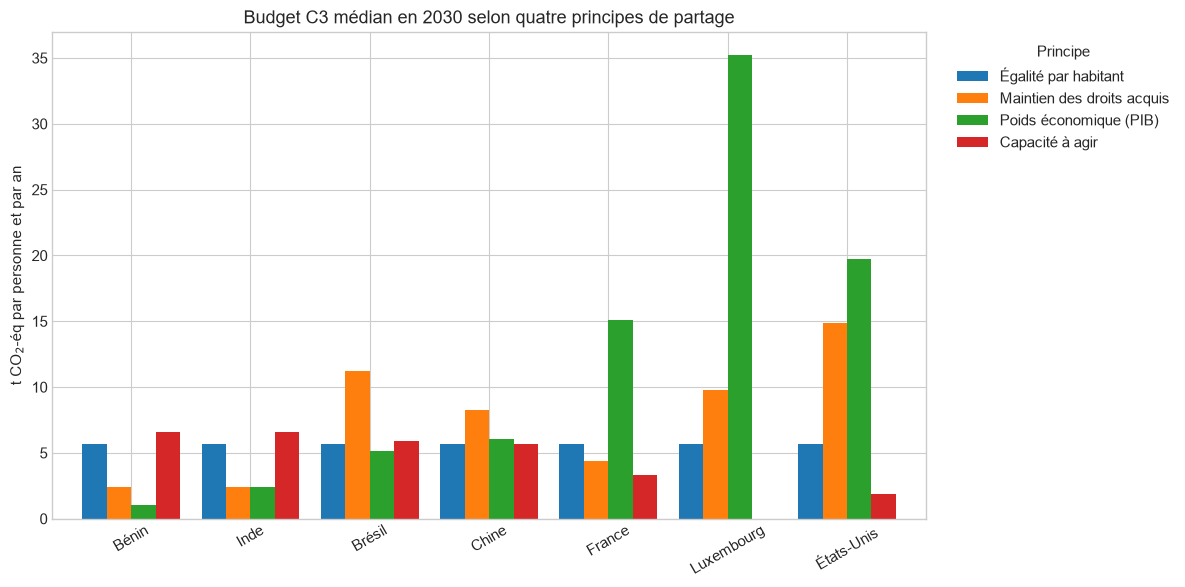

In [8]:
ax = a_tracer.plot(kind="bar", figsize=(12, 6), width=0.82)
ax.set(
    title="Budget C3 médian en 2030 selon quatre principes de partage",
    xlabel="", ylabel=r"t CO$_2$-éq par personne et par an"
)
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Principe", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES / "02_comparaison_principes_2030.png", dpi=180, bbox_inches="tight")
plt.show()

**Questions d'interprétation.**

1. Quelle règle reproduit les inégalités actuelles d'émissions ?
2. Pourquoi l'allocation proportionnelle au PIB et le maintien des droits acquis produisent-ils parfois des résultats proches ?
3. Une part plus élevée constitue-t-elle nécessairement un résultat plus « juste » ? Pour qui ?
4. Que change le passage d'un budget national à un budget par habitant ?
5. Quels résultats seraient différents avec une empreinte de consommation plutôt que des émissions territoriales ?

## 5. Tester la sensibilité des seuils de capacité

Le rapport EEA/FOEN retient trois couples de seuils pour cette méthode. Leur comparaison montre qu'une formule apparemment précise peut rester très sensible à des paramètres choisis par l'analyste.

In [9]:
seuils = {
    "10 000–100 000": (10_000, 100_000),
    "100–75 000": (100, 75_000),
    "7 500–50 000": (7_500, 50_000),
}
sensibilite = pd.DataFrame({
    nom: normaliser(poids_capacite(indicateurs, bas, haut))
    for nom, (bas, haut) in seuils.items()
})
sensibilite = sensibilite.loc[PAYS_COMPARAISON].mul(100)
sensibilite.index = [NOMS_FR.get(code, code) for code in PAYS_COMPARAISON]
sensibilite.index.name = "pays"
sensibilite.columns.name = "seuils de PIB/habitant (int.-$ PPA)"
sensibilite.round(3)

seuils de PIB/habitant (int.-$ PPA),10 000–100 000,100–75 000,7 500–50 000
pays,,,
Bénin,0.207,0.235,0.252
Inde,21.087,22.240,24.817
Brésil,2.784,2.761,2.739
Chine,17.919,17.404,16.302
France,0.495,0.322,0.000
Luxembourg,0.000,0.000,0.000
États-Unis,1.435,0.052,0.000


## 6. À vous d'explorer

Le rapport EEA/FOEN recense d'autres pistes : population cumulée, structure par âge, besoins nutritionnels, accessibilité, pauvreté, niveau de développement, superficie, biocapacité ou revenu cumulé. On rencontre aussi des approches fondées sur la responsabilité historique ou sur un droit minimal au développement.

### Mini-livrable préparatoire au poster

Choisissez un principe absent de ce notebook et produisez :

1. une définition en français et une référence vérifiable ;
2. la formule du ratio, avec son numérateur et son dénominateur ;
3. la source, l'unité et l'année de chaque donnée ;
4. un contrôle montrant que la somme des parts vaut 1 ;
5. une comparaison avec au moins deux principes de ce notebook ;
6. un paragraphe sur les hypothèses de justice, les entités avantagées et les limites de la méthode.

### Si vous utilisez un LLM

Demandez-lui des sources, puis consultez-les. Vérifiez que la formule correspond réellement au principe cité, que les unités sont compatibles, que les agrégats mondiaux ne sont pas comptés comme des pays et que les données manquantes ne disparaissent pas silencieusement. Un code qui s'exécute n'est pas encore une méthode défendable.

## Références de départ

- Service des données et études statistiques (SDES), [*La France face aux neuf limites planétaires — Quelles utilisations du cadre à l'échelle locale ?*](https://www.statistiques.developpement-durable.gouv.fr/edition-numerique/la-france-face-aux-neuf-limites-planetaires/partie3-quelles-utilisations-du-cadre-des-limites).
- European Environment Agency & FOEN (2020), *Is Europe living within the limits of our planet?* — copie locale dans doc/.
- Hjalsted et al. (2021), *Sharing the safe operating space: Exploring ethical allocation principles to operationalize the planetary boundaries*.
- Données démographiques : [Population, Our World in Data](https://ourworldindata.org/grapher/population).
- Banque mondiale et Our World in Data : [PIB en PPA](https://ourworldindata.org/grapher/gdp-worldbank) et [PIB par habitant en PPA](https://ourworldindata.org/grapher/gdp-per-capita-worldbank).
- [Émissions annuelles territoriales de GES incluant l'usage des sols, Our World in Data](https://ourworldindata.org/grapher/greenhouse-gas-emissions).
- IPCC (2022), *Climate Change 2022: Mitigation of Climate Change*.